### Imports

In [135]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Constants

In [136]:
MODEL_NAME = 'cnn_classifier'
MODEL_VERSION = 'v1.0'
MODEL_PATH = f'models/{MODEL_NAME}_{MODEL_VERSION}.keras'
LOAD_MODEL = False # Set to True if you want to load a pre-trained model
SAVE_MODEL = False

BEST_ACC_ON_TEST = 0.86
BEST_MODEL_VERSION = 'v1.0'

NO_CLASSES = 10
IMG_SIZE = 32
CHANNELS = 3

hyperparameters = {
    'initial_lr': 1e-3,
    'min_lr': 1e-6,
    'lr_decay_factor': 0.5,
    'lr_decay_patience': 3,
    'lr_decay_monitor': 'val_loss',
    
    'epochs': 2000,
    'batch_size': 32,
    'validation_split': 0.1,

    'early_stopping_patience': 7,
    'early_stopping_monitor': 'val_loss',

    'loss_fn': 'categorical_crossentropy', # suitable for one-hot encoded labels
    'metrics': ['accuracy'],
}

# Loading and preprocessing data

In [137]:
# Loading the CIFAR-10 dataset
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize the data between 0 and 1
x_train, x_test  = x_train / 255.0, x_test / 255.0

# One-hot encoding the labels
y_train = tf.keras.utils.to_categorical(y_train, NO_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, NO_CLASSES)

# Building the model

In [ ]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS), num_classes=NO_CLASSES):
    # Building the Convolutional Neural Network (CNN) model
    # - Convolutional layers to extract features from images
    # - MaxPooling layers to reduce the spatial dimensions of the feature maps
    #    - Goal: separate the feature extraction from reduction of dimensions
    # - Dropout layers to prevent overfitting
    return Sequential([
        # 1. Conv-Block
        Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.2),

        # 2. Conv-Block
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.2),

        # 3. Conv-Block
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.2),

        # Dense Layers
        Flatten(),
        Dense(512, activation='relu'),             
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

In [ ]:
if LOAD_MODEL:
    print(f"Loading model from {MODEL_PATH}")
    model = load_model(MODEL_PATH)
else:
    print("Building a new model")
    model = build_cnn()

model.compile(
    optimizer=Adam(learning_rate=hyperparameters['initial_lr']),
    loss=hyperparameters['loss_fn'], 
    metrics=hyperparameters['metrics']
)

model.summary()

Building a new model


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_90 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_90          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_91          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_92          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_93          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         5,13

 Total params: 1,343,018 (5.12 MB)

 Trainable params: 1,342,122 (5.12 MB)

 Non-trainable params: 896 (3.50 KB)

# Training & testing

In [140]:
lr_scheduler = ReduceLROnPlateau(
    monitor=hyperparameters['lr_decay_monitor'],
    factor=hyperparameters['lr_decay_factor'],
    patience=hyperparameters['lr_decay_patience'],
    min_lr=hyperparameters['min_lr']
)

early_stop = EarlyStopping(
    monitor=hyperparameters['early_stopping_monitor'],
    patience=hyperparameters['early_stopping_patience'],
    restore_best_weights=True  # save best weights during training (available in model itself after training)
)

history = model.fit(
    x_train,
    y_train,
    epochs=hyperparameters['epochs'],
    batch_size=hyperparameters['batch_size'],
    validation_split=hyperparameters['validation_split'],  # use x% of training data for validation
    callbacks=[early_stop]
)

eval_loss, eval_accuracy = model.evaluate(x_test, y_test)
print(f"Accuracy on test set: {eval_accuracy:.2f}\nBest Accuracy yet: {BEST_ACC_ON_TEST} using model with version {BEST_MODEL_VERSION}.")

Epoch 1/2000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.3788 - loss: 1.8871 - val_accuracy: 0.5670 - val_loss: 1.2009
Epoch 2/2000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5973 - loss: 1.1398 - val_accuracy: 0.5628 - val_loss: 1.3145
Epoch 3/2000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.6769 - loss: 0.9249 - val_accuracy: 0.7254 - val_loss: 0.7847
Epoch 4/2000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7188 - loss: 0.8163 - val_accuracy: 0.7386 - val_loss: 0.7542
Epoch 5/2000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7534 - loss: 0.7213 - val_accuracy: 0.7546 - val_loss: 0.7299
Epoch 6/2000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7831 - loss: 0.6341 - val_accuracy: 0.8054 - val_loss: 0.6077
Epoch 7/2000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.8008 - loss: 0.5881 - val_accuracy: 0.8048 - val_loss: 0.5712
Epoch 8/2000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - ac

In [141]:
if SAVE_MODEL or eval_accuracy > BEST_ACC_ON_TEST:
    model.save(MODEL_PATH)
    print(f"Saved model to {MODEL_PATH}!")

# Visualization

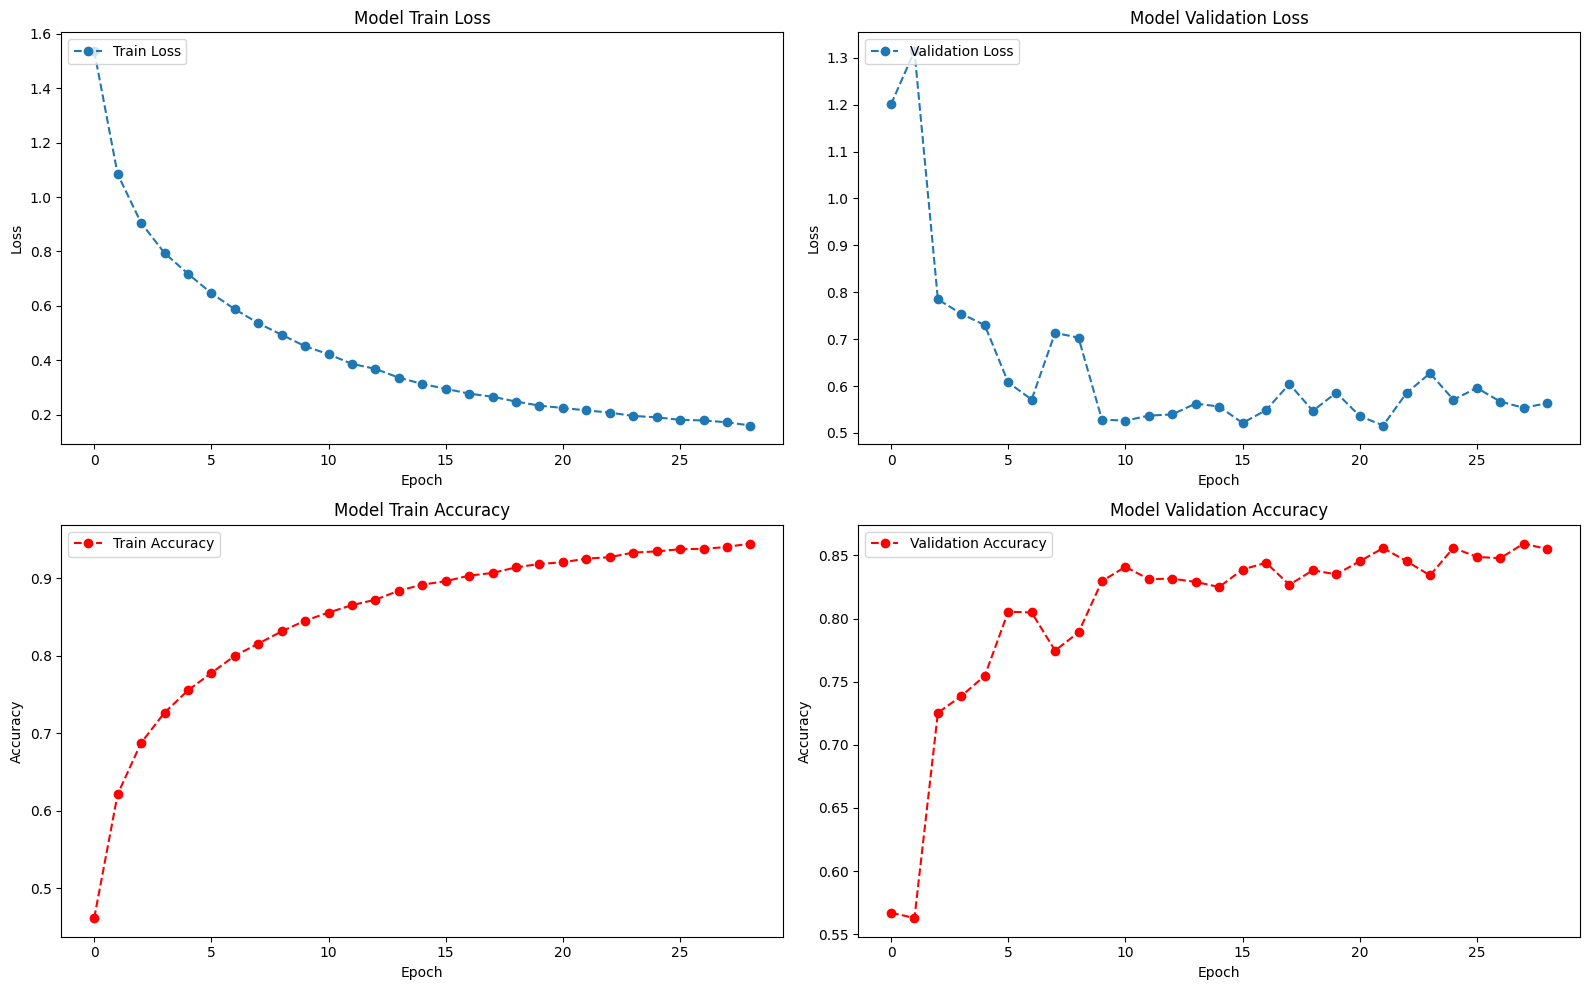

In [142]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))  # 1 Zeile, 2 Spalten

# Loss-Plot
axs[0][0].plot(history.history['loss'], 'o--')
axs[0][0].set_title('Model Train Loss')
axs[0][0].set_xlabel('Epoch')
axs[0][0].set_ylabel('Loss')
axs[0][0].legend(['Train Loss'], loc='upper left')

axs[0][1].plot(history.history['val_loss'], 'o--')
axs[0][1].set_title('Model Validation Loss')
axs[0][1].set_xlabel('Epoch')
axs[0][1].set_ylabel('Loss')
axs[0][1].legend(['Validation Loss'], loc='upper left')

# Accuracy-Plot
axs[1][0].plot(history.history['accuracy'], 'ro--')
axs[1][0].set_title('Model Train Accuracy')
axs[1][0].set_xlabel('Epoch')
axs[1][0].set_ylabel('Accuracy')
axs[1][0].legend(['Train Accuracy'], loc='upper left')

axs[1][1].plot(history.history['val_accuracy'], 'ro--')
axs[1][1].set_title('Model Validation Accuracy')
axs[1][1].set_xlabel('Epoch')
axs[1][1].set_ylabel('Accuracy')
axs[1][1].legend(['Validation Accuracy'], loc='upper left')

plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


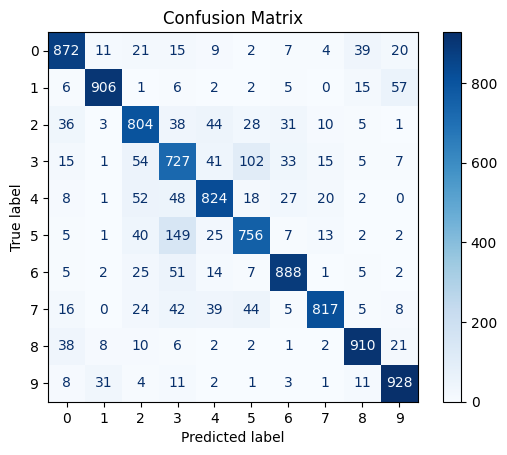

In [143]:
y_pred = model.predict(x_test)

y_pred_classes = y_pred.argmax(axis=1)
y_true_classes = y_test.argmax(axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()